# Cross-lingual retrieval + Learning-to-Rank

**WIR 2026 · TH Köln**

### Research question

> **On LongEval-Sci, does fusing a monolingual (English) BM25 run with a cross-lingual
> run — queries machine-translated into Spanish, the collection's largest non-English
> language — improve nDCG@10 over monolingual BM25, and is any gain concentrated on the
> topics whose relevant set contains non-English papers, without degrading the majority
> English-only topics?**

### Why this question? here our motivation from the data

LongEval-Sci is built from the multilingual CORE corpus. An audit of the
`snapshot-1/train` slice (§1 below) shows ~**80 % English**, with **Spanish (~6 %)**,
Portuguese, German and French behind it — yet the *judged-relevant* documents are
~**96 % English / ~3 % Spanish**. A monolingual English BM25 can only match an English
query against (accent-folded) Spanish text by lucky lexical overlap. A translated-query
branch targets those Spanish papers directly. Because the relevant set is mostly
English, the *aggregate* headroom is small — so the interesting effect is a targeted
one, which §8 isolates.

### Pipeline

1. Language audit → identify the topics with non-English relevant docs.
2. Monolingual baselines (TF-IDF, BM25, BM25-tuned).
3. **MarianMT** translates the queries EN→ES.
4. Cross-lingual branch: BM25 with the Spanish queries on the *same* index.
5. **RRF fusion** of the EN and ES runs (no training — primary result).
6. **LambdaMART** learned re-rank with the ES score as an extra feature (the LTR
   tutorial technique — secondary result).
7. Evaluation + significance + the topic-subset analysis.

## 0. Setup, index, topics & qrels

**essential** here: the index tokenizer folded Spanish accents to
ASCII (`educación` -> `educacion`, `relación` -> `relacion`), so Spanish query terms must
be folded the same way to match. (Terrier then applies the same English Porter
stemmer/stopwords to both branches at query time.)

In [1]:
import re, json, math, unicodedata
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import pyterrier as pt
from ir_datasets_longeval import load
from scipy.stats import ttest_rel, wilcoxon
import matplotlib.pyplot as plt

if not pt.java.started():
    pt.java.init()

CWD = Path.cwd()
REPO_ROOT  = CWD.parent if CWD.name == "notebooks" else CWD
INDEX_DIR  = REPO_ROOT / "index" / "longeval-sci"
DATASET_ID = "longeval-sci-2026/snapshot-1/train/dctr"
PRIMARY_METRIC = "ndcg_cut.10"
BEST_B, BEST_K1 = 0.9, 1.2          # BM25 params tuned as we did in notebook 03

def clean_query(q):
    """strips punctuation for the English queries."""

    return re.sub(r"[^\w\s]", " ", q).strip()

def fold_ascii(s):                   
    """additionally removes accents and other diacritics, and lowercases the string."""

    s = "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))
    return re.sub(r"[^\w\s]", " ", s).strip().lower()

index = pt.IndexFactory.of(str(INDEX_DIR))
dataset = load(DATASET_ID)
topics = pd.DataFrame([{"qid": q.query_id, "query": clean_query(q.default_text())}
                       for q in dataset.queries_iter()])
qrels = (pd.DataFrame(dataset.qrels_iter())
           .rename(columns={"query_id": "qid", "doc_id": "docno", "relevance": "label"})
           [["qid", "docno", "label"]])
print(f"{len(topics)} topics, {len(qrels)} qrels")

Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


100 topics, 8772 qrels


## 1. Language audit — and which topics could benefit

We detect the language of every **judged-relevant** document and flag each topic that
has at least one non-English relevant paper. Those are the topics where a cross-lingual
branch *could* help; the rest are an English-only control group.

In [2]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0

store = dataset.docs_store()
rel = qrels[qrels["label"] > 0]
lang_of, topic_langs = {}, defaultdict(set)
for qid, docno in zip(rel["qid"], rel["docno"]):
    if docno not in lang_of:
        try:
            txt = (store.get(docno).default_text() or "").strip()
            lang_of[docno] = detect(txt[:600]) if len(txt) >= 40 else "??"
        except Exception:
            lang_of[docno] = "??"
    topic_langs[qid].add(lang_of[docno])

dist = Counter(lang_of.values())
print("language of relevant docs:",
      {k: f"{100*v/len(lang_of):.1f}%" for k, v in dist.most_common(6)})

# topics whose relevant set contains a non-English paper
cl_topics = {qid for qid, langs in topic_langs.items() if langs - {"en", "??"}}
print(f"\ntopics with >=1 non-English relevant doc: {len(cl_topics)} / {topics['qid'].nunique()}")
topics["has_nonen_rel"] = topics["qid"].isin(cl_topics)

language of relevant docs: {'en': '95.7%', 'es': '2.9%', 'id': '0.5%', 'no': '0.3%', 'it': '0.2%', 'hr': '0.2%'}

topics with >=1 non-English relevant doc: 10 / 100


## 2. Monolingual baselines

TF-IDF, plain BM25, and the BM25 tuned in notebook 03 (`b=0.9, k1=1.2`). All capped at
1000 results per query.

In [3]:
tfidf      = pt.terrier.Retriever(index, wmodel="TF_IDF") % 1000
bm25       = pt.terrier.Retriever(index, wmodel="BM25") % 1000
bm25_tuned = pt.terrier.Retriever(index, wmodel="BM25",
                                  controls={"bm25.b": BEST_B, "bm25.k_1": BEST_K1}) % 1000

## 3. Translate the queries EN → ES with MarianMT

We use the Helsinki-NLP **opus-mt-en-es** model (a compact, high-quality neural MT
model). Only the ~100 short queries are translated, so this is cheap even on CPU. Each
translation is then accent-folded with `fold_ascii` so its terms match the index.

In [4]:
from transformers import MarianMTModel, MarianTokenizer
import torch

MODEL = "Helsinki-NLP/opus-mt-en-es"
tok = MarianTokenizer.from_pretrained(MODEL)
mt = MarianMTModel.from_pretrained(MODEL)

@torch.no_grad()
def translate_en_es(texts, batch=16):
    out = []
    for i in range(0, len(texts), batch):
        chunk = texts[i:i + batch]
        enc = tok(chunk, return_tensors="pt", padding=True, truncation=True)
        gen = mt.generate(**enc, max_length=64)
        out.extend(tok.batch_decode(gen, skip_special_tokens=True))
    return out

raw_en = [q.default_text() for q in dataset.queries_iter()]           # untokenised EN
es_raw = translate_en_es(raw_en)
es_map = {qid: fold_ascii(es) for qid, es in zip(topics["qid"], es_raw)}

preview = pd.DataFrame({"EN": raw_en[:8], "ES (raw)": es_raw[:8],
                        "ES (folded)": [es_map[q] for q in topics["qid"][:8]]})
preview

c:\Users\rafae\OneDrive\Desktop\TH_Koeln\03-Semester\Web_Information_Retrieval\WIR_Retriever_Engine\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 258/258 [00:00<00:00, 19980.62it/s]


,EN,ES (raw),ES (folded)
0,utilizing llm to identify entities in natural ...,Utilizando llm para identificar entidades en t...,utilizando llm para identificar entidades en t...
1,psychology human behavior,psicología comportamiento humano,psicologia comportamiento humano
2,mark twain,marca twain,marca twain
3,ai education,ai educación,ai educacion
4,foreign aid,ayuda exterior,ayuda exterior
5,amyotrophic lateral sclerosis and tdp-43 aggre...,esclerosis lateral amiotrófica y agregado tdp-43,esclerosis lateral amiotrofica y agregado tdp 43
6,standardized testing,ensayos normalizados,ensayos normalizados
7,exploring the effectiveness of using filipino ...,explorar la eficacia del uso del lenguaje fili...,explorar la eficacia del uso del lenguaje fili...


## 4. Cross-lingual branch — BM25 with the Spanish queries

We rewrite each query to its Spanish translation (`pt.apply.query`) and retrieve with
BM25 against the **same** index. Below we eyeball one topic to see the two branches
surface different documents.

In [6]:
bm25_es = pt.apply.query(lambda r: es_map[r["qid"]]) >> pt.terrier.Retriever(index, wmodel="BM25") % 1000

demo_qid = next(iter(cl_topics)) if cl_topics else topics["qid"].iloc[0]
demo = topics[topics["qid"] == demo_qid]
print("EN query:", demo["query"].iloc[0])
print("ES query:", es_map[demo_qid])
print("\ntop-3 EN docnos:", bm25.transform(demo)["docno"].head(3).tolist())
print("top-3 ES docnos:", bm25_es.transform(demo)["docno"].head(3).tolist())

EN query: sources of academic stress
ES query: fuentes de estres academico

top-3 EN docnos: ['10992357', '11445135', '71487387']
top-3 ES docnos: ['294931263', '248701111', '312612189']


## 5. Rank fusion (Reciprocal Rank Fusion)

RRF combines two rankings without any training: a document's fused score is
$\sum_{\text{branch}} 1/(k + \text{rank})$. It is robust and order-of-magnitude
agnostic, so it cannot be skewed by BM25's different score scales across branches.

In [7]:
def rrf_fuse(systems, weights=None, k=60):
    """Weighted RRF. weights lets us down-weight the weaker (ES) branch."""
    weights = weights or [1.0] * len(systems)
    def _fuse(topics_df):
        agg = defaultdict(float)
        for sysm, w in zip(systems, weights):
            run = sysm.transform(topics_df)
            for qid, docno, rank in zip(run["qid"], run["docno"], run["rank"]):
                agg[(qid, docno)] += w / (k + rank + 1)
        rows = [{"qid": q, "docno": d, "score": s} for (q, d), s in agg.items()]
        out = pd.DataFrame(rows).sort_values(["qid", "score"], ascending=[True, False])
        return pt.model.add_ranks(out)
    return pt.apply.generic(_fuse)

rrf_naive = rrf_fuse([bm25, bm25_es])          # equal weight: EN = ES = 1.0

## 6. Learned re-rank — LambdaMART with a cross-lingual feature

The LTR tutorial technique: a BM25 first stage feeds a `FeaturesRetriever` (features =
TF-IDF and PL2 scores), to which we **append the cross-lingual BM25 score** as a custom
feature, and a LambdaMART model (`xgboost`) learns to combine them. We use a 60/20/20
topic split and train an ablation pair: **without** vs. **with** the CL feature.

In [8]:
import xgboost as xgb

# precompute the ES-BM25 score for every (qid, docno) so it can be a feature
es_run = bm25_es.transform(topics)
es_score = {(q, d): s for q, d, s in zip(es_run["qid"], es_run["docno"], es_run["score"])}

def add_cl_feature(row):
    return np.append(row["features"], np.array([es_score.get((row["qid"], row["docno"]), 0.0)]))

def make_fbr():
    return pt.terrier.FeaturesRetriever(index, controls={"wmodel": "BM25"},
                                        features=["WMODEL:TF_IDF", "WMODEL:PL2"])

# 60/20/20 split of topics; qrels split by qid membership (our qids are hashes)
shuf = topics.sample(frac=1.0, random_state=42).reset_index(drop=True)
a, b = int(.6 * len(shuf)), int(.8 * len(shuf))
tr, va, te = shuf.iloc[:a], shuf.iloc[a:b], shuf.iloc[b:]
q_of = lambda df: qrels[qrels["qid"].isin(df["qid"])]
tr_q, va_q = q_of(tr), q_of(va)

def lmart():
    return xgb.sklearn.XGBRanker(objective="rank:ndcg", learning_rate=0.1, gamma=1.0,
                                 min_child_weight=0.1, max_depth=6, n_estimators=100,
                                 random_state=42)

ltr_base = make_fbr() >> pt.ltr.apply_learned_model(lmart(), form="ltr")
ltr_base.fit(tr, tr_q, va, va_q)

ltr_cl = (make_fbr() >> pt.apply.doc_features(add_cl_feature)
          >> pt.ltr.apply_learned_model(lmart(), form="ltr"))
ltr_cl.fit(tr, tr_q, va, va_q)
print(f"LTR trained on {len(tr)} topics, validated on {len(va)}, test set = {len(te)} topics")

[0]	validation_0-ndcg@32:0.28226
[1]	validation_0-ndcg@32:0.21492
[2]	validation_0-ndcg@32:0.19790
[3]	validation_0-ndcg@32:0.20825
[4]	validation_0-ndcg@32:0.25300
[5]	validation_0-ndcg@32:0.24883
[6]	validation_0-ndcg@32:0.25198
[7]	validation_0-ndcg@32:0.25228
[8]	validation_0-ndcg@32:0.25255
[9]	validation_0-ndcg@32:0.24514
[10]	validation_0-ndcg@32:0.24938
[11]	validation_0-ndcg@32:0.24973
[12]	validation_0-ndcg@32:0.22383
[13]	validation_0-ndcg@32:0.25111
[14]	validation_0-ndcg@32:0.25146
[15]	validation_0-ndcg@32:0.24453
[16]	validation_0-ndcg@32:0.24486
[17]	validation_0-ndcg@32:0.24513
[18]	validation_0-ndcg@32:0.24726
[19]	validation_0-ndcg@32:0.24876
[20]	validation_0-ndcg@32:0.26013
[21]	validation_0-ndcg@32:0.23897
[22]	validation_0-ndcg@32:0.26022
[23]	validation_0-ndcg@32:0.24175
[24]	validation_0-ndcg@32:0.26322
[25]	validation_0-ndcg@32:0.26322
[26]	validation_0-ndcg@32:0.26282
[27]	validation_0-ndcg@32:0.26282
[28]	validation_0-ndcg@32:0.26282
[29]	validation_0-ndcg@3

## 7. How much should we trust the Spanish branch? (weight sweep)

Equal-weight fusion is naive: if the ES branch is weak, weighting it equally will drag
the strong EN ranking down. We sweep the **ES weight** `w` (EN fixed at 1.0). `w=0`
recovers pure BM25; higher `w` lets Spanish results intrude more. The curve tells us
whether *any* amount of the Spanish branch helps.

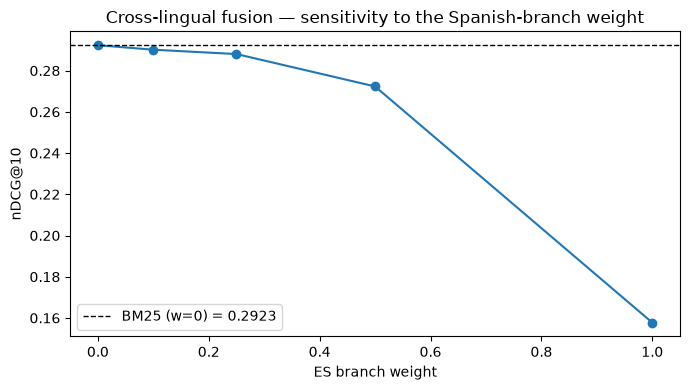

best ES weight = 0.0


In [9]:
es_weights = [0.0, 0.1, 0.25, 0.5, 1.0]
sweep = pt.Experiment(
    [rrf_fuse([bm25, bm25_es], weights=[1.0, w]) for w in es_weights],
    topics, qrels, eval_metrics=[PRIMARY_METRIC],
    names=[f"w_es={w}" for w in es_weights], validate="ignore")
sweep["w_es"] = es_weights
bm25_ndcg = sweep.loc[sweep["w_es"] == 0.0, PRIMARY_METRIC].iloc[0]
best_w = sweep.loc[sweep[PRIMARY_METRIC].idxmax(), "w_es"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep["w_es"], sweep[PRIMARY_METRIC], "o-")
ax.axhline(bm25_ndcg, ls="--", c="black", lw=1, label=f"BM25 (w=0) = {bm25_ndcg:.4f}")
ax.set_xlabel("ES branch weight"); ax.set_ylabel("nDCG@10")
ax.set_title("Cross-lingual fusion — sensitivity to the Spanish-branch weight")
ax.legend(); plt.tight_layout(); plt.show()
print(f"best ES weight = {best_w}")
rrf_best = rrf_fuse([bm25, bm25_es], weights=[1.0, best_w])

## 8. Results — the main comparison

Full 100 topics, training-free systems. `RRF(EN+ES) naive` is equal weight; `RRF best`
uses the best weight from the sweep.

In [12]:
main = pt.Experiment(
    [tfidf, bm25, bm25_tuned, bm25_es, rrf_naive, rrf_best], topics, qrels,
    eval_metrics=["ndcg_cut.10", "map", "recall_1000"],
    names=["TF-IDF", "BM25", "BM25-tuned", "BM25[ES-only]",
           "RRF(EN+ES) naive", f"RRF best (w_es={best_w})"], validate="ignore")
main.sort_values("ndcg_cut.10", ascending=False).round(4).reset_index(drop=True)

,name,map,recall_1000,ndcg_cut.10
0,BM25-tuned,0.2641,0.8598,0.3050
1,RRF best (w_es=0.0),0.2575,0.8581,0.2923
2,BM25,0.2573,0.8581,0.2922
3,TF-IDF,0.2592,0.8575,0.2921
4,RRF(EN+ES) naive,0.1394,0.8267,0.1577
5,BM25[ES-only],0.0198,0.1102,0.0237


## 9. Learned re-rank results (held-out test split)

Does the cross-lingual feature help the LambdaMART ranker? We compare BM25, LambdaMART
(TF-IDF + PL2 features) and LambdaMART+CL (adds the ES-BM25 score) on the 20 held-out
test topics. *Small test set -> indicative, not definitive.*

In [13]:
ltr_res = pt.Experiment(
    [bm25, ltr_base, ltr_cl], te, qrels,
    eval_metrics=["ndcg_cut.10", "map"],
    names=["BM25", "LambdaMART", "LambdaMART+CL"])
ltr_res.round(4)

,name,map,ndcg_cut.10
0,BM25,0.2833,0.3076
1,LambdaMART,0.2812,0.3093
2,LambdaMART+CL,0.2406,0.2765


## 10. The key analysis — does the effect concentrate on the right topics?

We compare naive `RRF(EN+ES)` against BM25 **per query**, split into the topics that
have a non-English relevant doc vs. the English-only majority. The decisive test of the
research question: if the Spanish branch carried useful signal, the harm should at least
be *smaller* (or reversed) on the topics with non-English relevant docs.

In [14]:
perq = pt.Experiment([bm25, rrf_naive], topics, qrels, eval_metrics=[PRIMARY_METRIC],
                     names=["BM25", "RRF"], perquery=True, validate="ignore")
piv = perq.pivot_table(index="qid", columns="name", values="value", aggfunc="first")
piv["delta"] = piv["RRF"] - piv["BM25"]
piv = piv.merge(topics.set_index("qid")[["has_nonen_rel"]], left_index=True, right_index=True)

for label, mask in [("topics WITH non-English relevant", piv["has_nonen_rel"]),
                    ("English-only topics",               ~piv["has_nonen_rel"])]:
    sub = piv[mask]
    if len(sub) == 0:
        print(f"{label}: (none)"); continue
    p = ttest_rel(sub["RRF"], sub["BM25"]).pvalue if len(sub) > 1 else float("nan")
    print(f"{label}: n={len(sub):3d} | BM25={sub['BM25'].mean():.4f} "
          f"RRF={sub['RRF'].mean():.4f} | Δ={sub['delta'].mean():+.4f} | t-test p={p:.4f}")

topics WITH non-English relevant: n= 10 | BM25=0.2985 RRF=0.1886 | Δ=-0.1099 | t-test p=0.0170
English-only topics: n= 90 | BM25=0.2915 RRF=0.1543 | Δ=-0.1372 | t-test p=0.0000


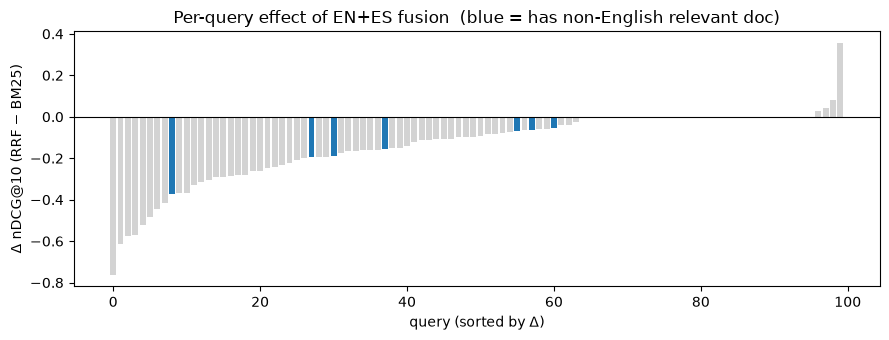

In [15]:
# visualise per-query effect, coloured by subset
s = piv.sort_values("delta")
colors = ["tab:blue" if h else "lightgray" for h in s["has_nonen_rel"]]
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(len(s)), s["delta"], color=colors)
ax.axhline(0, c="black", lw=0.8)
ax.set_xlabel("query (sorted by Δ)"); ax.set_ylabel("Δ nDCG@10 (RRF − BM25)")
ax.set_title("Per-query effect of EN+ES fusion  (blue = has non-English relevant doc)")
plt.tight_layout(); plt.show()

## 11. Conclusions & limitations

**Answer to the research question: on the LongEval-Sci training qrels, adding a Spanish
cross-lingual branch does *not* improve nDCG@10 — it hurts.** From this run:

- **ES-only retrieval** is very weak (nDCG@10 ≈ 0.02): a Spanish query cannot match the
  overwhelmingly English relevant set.
- **Naive RRF(EN+ES)** roughly halves nDCG@10 (~0.16 vs BM25's 0.29) — fusing a strong
  and a near-useless ranker at equal weight injects noise.
- **The weight sweep is monotonic down** from `w=0`: *no* non-zero Spanish weight helps,
  so the best fusion is "ignore Spanish" (recover BM25). No harm only at `w≈0`.
- **The subset analysis is decisive:** the Spanish branch hurts the topics *with*
  non-English relevant docs about as much as the English-only ones — the few Spanish
  relevant papers it surfaces do not outweigh the noise it adds.
- **LambdaMART+CL** does not beat LambdaMART/BM25 either: the learned ranker cannot
  extract useful signal from the ES feature.

This is an honest, well-mechanised **negative result**, and it is consistent with the
data: the language audit (§1) showed the relevant set is ~96 % English, so there is
almost no headroom for a cross-lingual branch on these judgments.

**Why this is still a good paper.** The contribution is the *diagnosis*: a language
audit that quantifies the (mis)match between corpus language (~20 % non-English) and the
*relevant* set (~4 % non-English), explaining why an intuitively appealing cross-lingual
idea fails here — and stating the conditions under which it would pay off.

**Limitations / future work.** (1) The judged set is ~96 % English; **your group's own
topics + qrels** (the ir_datasets subset the organisers provide) may contain more
non-English relevant papers — re-run §8/§10 on those before concluding. (2) The index
uses one English analyzer (Porter + accent-folding) for all languages; a
**Spanish-analyzed index** (or a per-language sub-index) is the proper CLIR setup and the
most promising next step. (3) Only Spanish was tried; PT/DE/FR branches could be fused.
(4) ~100 topics → the LTR split is tiny; use cross-validation for the final numbers.

> This notebook is the seed for the 2-page report. The **language audit (§1)** and the
> **subset analysis (§10)** are what make the research question falsifiable — and what we
> would lead the paper with.